In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread('cat.jpg')

# Rotate

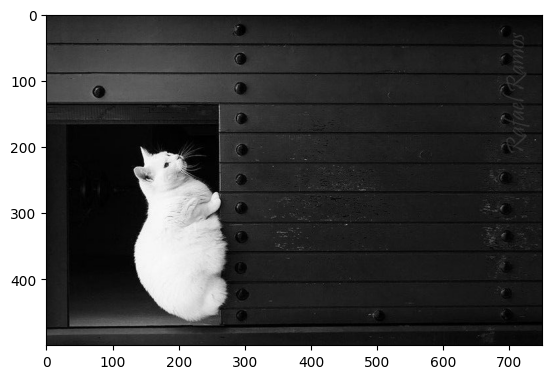

In [5]:
rotated = cv2.rotate(image,cv2.ROTATE_90_COUNTERCLOCKWISE)
plt.imshow(rotated)
# plt.imshow(cv2.cvtColor(rotated,cv2.COLOR_BGR2RGB))
plt.show()

# Translation
Translation means moving an image from one position to another without rotating or changing its size

In [8]:
import numpy as np

M = np.float32([
    [1,0,100],
    [0,1,50]
])

h,w= image.shape[:2]

In [10]:
h

750

In [11]:
w

500

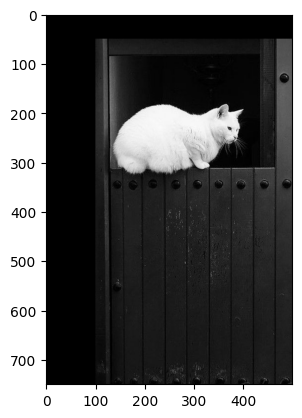

In [9]:
translated = cv2.warpAffine(image,M,(w,h))
plt.imshow(cv2.cvtColor(translated,cv2.COLOR_BGR2RGB))
plt.show()

# Scaling & zooming
Scaling means changing the size of an image

In [12]:
image.shape

(750, 500, 3)

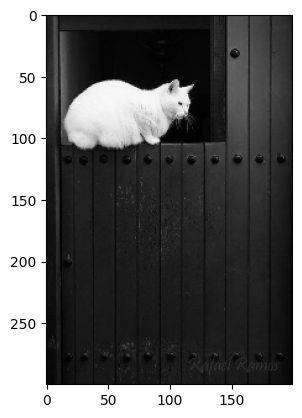

In [17]:
small = cv2.resize(image,(200,300))
plt.imshow(cv2.cvtColor(small,cv2.COLOR_BGR2RGB))
plt.show()

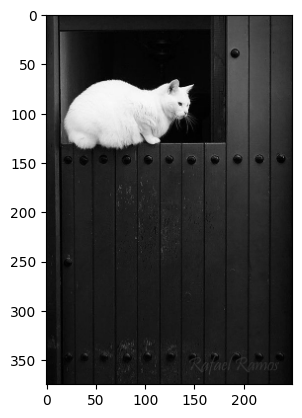

In [18]:
small = cv2.resize(image,None,fx=0.5,fy=0.5)
plt.imshow(cv2.cvtColor(small,cv2.COLOR_BGR2RGB))
plt.show()

Zooming is basically scaling up.

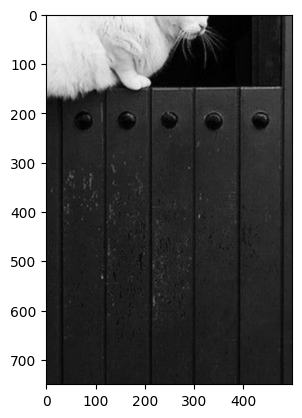

In [ ]:
zoom = cv2.resize(image,None,fx=2,fy=2)

h,w = image.shape[:2]

zoomed_view = zoom[h//2:h//2+h,
                   w//2:w//2+w]

plt.imshow(zoomed_view,cmap='gray')
plt.show()

In [22]:
print(image.shape)
print(zoom.shape)

(750, 500, 3)
(1500, 1000, 3)


# Perspective transforms

A perspective transform is a geometric operation that changes the viewpoint of an image by mapping a selected quadrilateral region (defined by 4 points) in the original image to a new rectangular shape in the output image, correcting distortion caused by camera angle.

In [29]:
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [30]:
pts1 = np.float32([
    [100, 150],   # top-left
    [400, 130],   # top-right
    [120, 500],   # bottom-left
    [420, 520]    # bottom-right
])

pts2 = np.float32([
    [0, 0],
    [300, 0],
    [0, 400],
    [300, 400]
])

In [31]:
matrix = cv2.getPerspectiveTransform(pts1, pts2)

In [33]:
warped = cv2.warpPerspective(image, matrix, (300, 400))


In [34]:
warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)


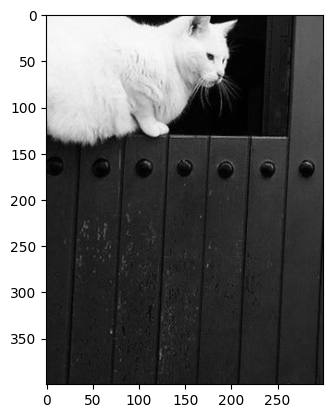

In [36]:
plt.imshow(warped_rgb)

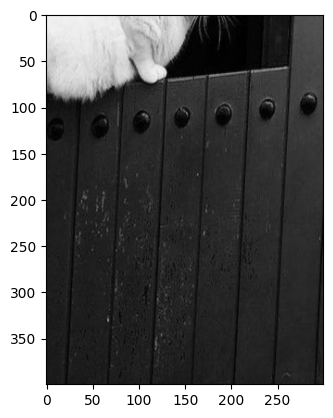

In [43]:
#test

gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

pts1 = np.float32([
    [100,200],
    [400,220],
    [120,500],
    [420,530]
])
pts2 = np.float32([
    [0,0],
    [300,0],
    [0,400],
    [300,400]
])

metrices = cv2.getPerspectiveTransform(pts1,pts2)

wraper = cv2.warpPerspective(image,metrices,(300,400))

plt.imshow(cv2.cvtColor(wraper,cv2.COLOR_BGR2RGB))



# Brightness & contrast adjustment


new_image = α * image + β
- alpha = contract
- beta = brightness

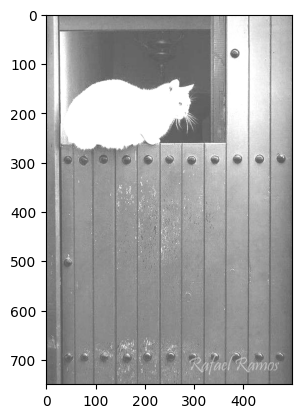

In [50]:
alpha = 2
beta = 90

adjusted = cv2.convertScaleAbs(image,alpha=alpha,beta=beta)

adjusted_rgb = cv2.cvtColor(adjusted,cv2.COLOR_BGR2RGB)
plt.imshow(adjusted_rgb)
plt.show()

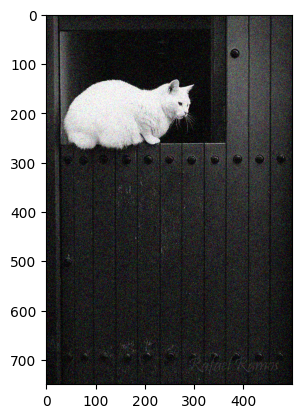

In [51]:
img = image.astype(np.float32)

mean = 0
sigma = 25

noise = np.random.normal(mean, sigma, img.shape)

noisy = img + noise

noisy = np.clip(noisy, 0, 255).astype(np.uint8)

noisy_rgb = cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB)

plt.imshow(noisy_rgb)

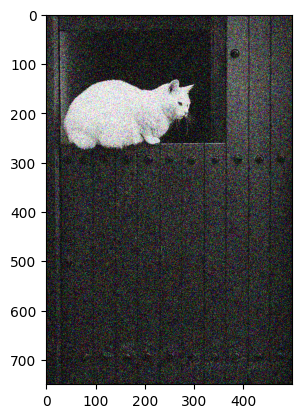

In [57]:
img = image.astype(np.float32)

mean=0
sigma=60

noise = np.random.normal(mean,sigma,img.shape)

noisy = noise+img 

noisy = np.clip(noisy,0,255).astype(np.uint8)

plt.imshow(cv2.cvtColor(noisy,cv2.COLOR_BGR2RGB))
plt.show()
